# STEP 1: Data Understanding
## About the Datasets:
1. VIIRS 375m (NOAA-20) → High resolution, small fires
2. VIIRS 375m (Suomi NPP) → Cross-validation
3. MODIS 1km (Terra/Aqua) → Large-scale, historical consistency

## Key Insight:
VIIRS detects more, smaller fires, while MODIS captures broader fire events.

# STEP 2: Data Preparation

In [1]:
# Importing the libraries
import pandas as pd
import numpy as np


## Load the dataset
viirs_noaa20 = pd.read_csv("fire_nrt_J1V-C2_565335.csv")
modis = pd.read_csv("fire_nrt_M-C61_565334.csv")
viirs_snpp = pd.read_csv("fire_nrt_SV-C2_565336.csv")

## Adding "SOURCE" Column this is to check and compare MODIS and VIIRS
viirs_noaa20["source"] = "VIIRS_NOAA20"
viirs_snpp["source"] = "VIIRS_SNPP"
modis["source"] = "MODIS"

### Combining all the datasets
df = pd.concat([viirs_noaa20, viirs_snpp, modis], ignore_index=True)

### Checking the data
df.shape
df.head()


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,source
0,70.39933,68.27425,323.29,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,258.44,3.14,N,VIIRS_NOAA20
1,70.39788,68.27815,338.50,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,260.52,3.08,N,VIIRS_NOAA20
2,70.38014,68.29300,320.24,0.32,0.55,2024-11-01,43,N20,VIIRS,n,2.0NRT,254.21,1.92,N,VIIRS_NOAA20
3,65.77070,24.18973,323.35,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,266.97,1.64,N,VIIRS_NOAA20
4,65.76741,24.18719,338.44,0.41,0.37,2024-11-01,48,N20,VIIRS,n,2.0NRT,269.87,5.80,N,VIIRS_NOAA20


In [2]:
### Confidence Bucketing
def normalize_confidence(conf):
    # If already numeric (MODIS)
    if isinstance(conf, (int, float)):
        return conf
    
    # VIIRS confidence mapping
    conf = str(conf).lower()
    if conf == "l":
        return 30
    elif conf == "n":
        return 60
    elif conf == "h":
        return 90
    else:
        return np.nan

df["confidence_numeric"] = df["confidence"].apply(normalize_confidence)

def confidence_level(conf):
    if conf <= 30:
        return "Low"
    elif conf <= 70:
        return "Medium"
    else:
        return "High"

df["confidence_level"] = df["confidence_numeric"].apply(confidence_level)


df[["confidence", "confidence_numeric", "confidence_level"]].head(10)


,confidence,confidence_numeric,confidence_level
0,n,60,Medium
1,n,60,Medium
2,n,60,Medium
3,n,60,Medium
4,n,60,Medium
5,n,60,Medium
6,n,60,Medium
7,n,60,Medium
8,n,60,Medium
9,n,60,Medium


In [3]:
## Encode day/night
df["is_night"] = df["daynight"].map({"D": 0, "N": 1})
df[["daynight", "is_night"]].head(10)


,daynight,is_night
0,N,1
1,N,1
2,N,1
3,N,1
4,N,1
5,N,1
6,N,1
7,N,1
8,N,1
9,N,1


In [4]:
df["is_night"].value_counts()


is_night
0    5665294
1    1646870
Name: count, dtype: int64

In [5]:
## Fire Intensity Categories (FRP-based)
df["frp_level"] = pd.qcut(
    df["frp"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df[["frp", "frp_level"]].head(10)

,frp,frp_level
0,3.14,Low
1,3.08,Low
2,1.92,Low
3,1.64,Low
4,5.80,Medium
5,3.67,Medium
6,2.73,Low
7,22.72,High
8,4.97,Medium
9,1.89,Low


In [6]:
df["frp_level"].value_counts()


frp_level
Low       2440541
High      2436272
Medium    2435351
Name: count, dtype: int64

In [7]:
df.groupby("frp_level")["frp"].describe()


,count,mean,std,min,25%,50%,75%,max
frp_level,,,,,,,,
Low,2440541.0,2.032053,0.938080,0.00,1.20,2.06,2.85,3.61
Medium,2435351.0,5.456300,1.201835,3.62,4.41,5.32,6.42,7.89
High,2436272.0,25.058123,51.907476,7.90,10.10,14.04,24.15,8371.39


In [8]:
### Combined Night vs Day Fire Intensity
pd.crosstab(df["frp_level"], df["is_night"])


is_night,0,1
frp_level,,
Low,1156809,1283732
Medium,2237469,197882
High,2271016,165256


In [9]:
### final sanity checks
df.info()
df.describe()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312164 entries, 0 to 7312163
Data columns (total 19 columns):
 #   Column              Dtype   
---  ------              -----   
 0   latitude            float64 
 1   longitude           float64 
 2   brightness          float64 
 3   scan                float64 
 4   track               float64 
 5   acq_date            object  
 6   acq_time            int64   
 7   satellite           object  
 8   instrument          object  
 9   confidence          object  
 10  version             object  
 11  bright_t31          float64 
 12  frp                 float64 
 13  daynight            object  
 14  source              object  
 15  confidence_numeric  int64   
 16  confidence_level    object  
 17  is_night            int64   
 18  frp_level           category
dtypes: category(1), float64(7), int64(3), object(8)
memory usage: 1011.1+ MB


latitude              0
longitude             0
brightness            0
scan                  0
track                 0
acq_date              0
acq_time              0
satellite             0
instrument            0
confidence            0
version               0
bright_t31            0
frp                   0
daynight              0
source                0
confidence_numeric    0
confidence_level      0
is_night              0
frp_level             0
dtype: int64

# STEP 3A: TEMPORAL VISUALIZATIONS (WHEN)

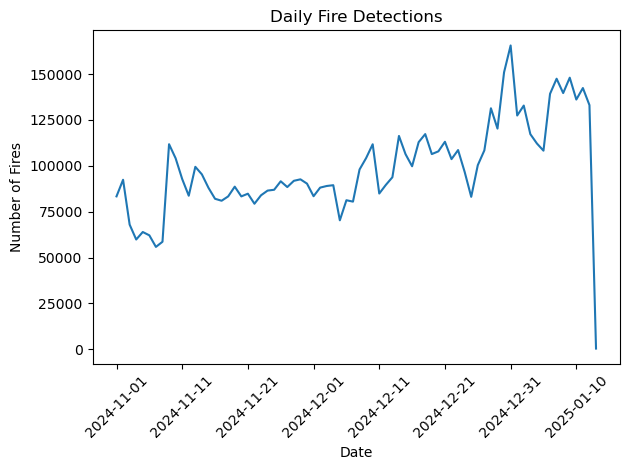

In [10]:
### Fires per day
import matplotlib.pyplot as plt

fires_per_day = df.groupby("acq_date").size()

plt.figure()
fires_per_day.plot()
plt.title("Daily Fire Detections")
plt.xlabel("Date")
plt.ylabel("Number of Fires")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


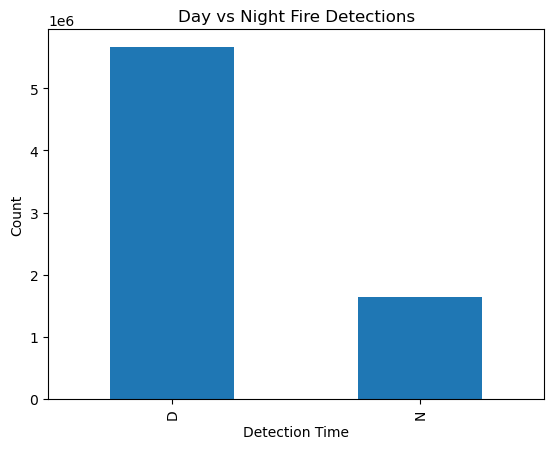

In [11]:
### day and night fires
plt.figure()
df["daynight"].value_counts().plot(kind="bar")
plt.title("Day vs Night Fire Detections")
plt.xlabel("Detection Time")
plt.ylabel("Count")
plt.show()


# STEP 3B: SPATIAL VISUALIZATIONS (WHERE)

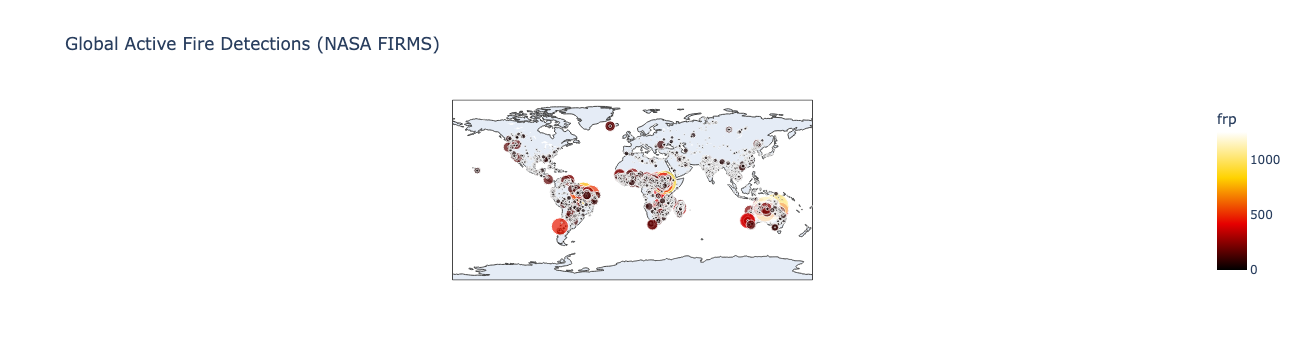

In [12]:
# Interactive Global Fire Map (FRP-colored)
import plotly.express as px

fig = px.scatter_geo(
    df.sample(20000),   # sampling for performance
    lat="latitude",
    lon="longitude",
    color="frp",
    size="frp",
    hover_name="source",
    color_continuous_scale="hot",
    title="Global Active Fire Detections (NASA FIRMS)"
)

fig.show()


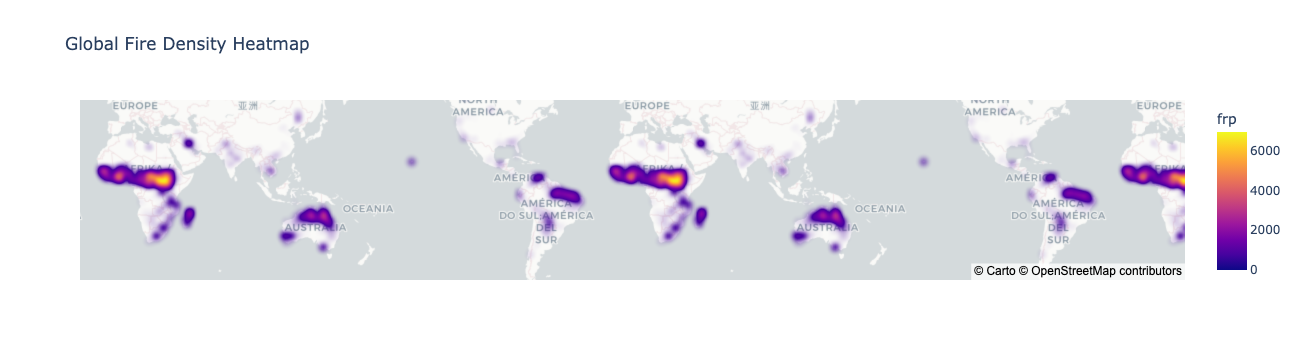

In [13]:
## Fire Density Heatmap
fig = px.density_mapbox(
    df.sample(30000),
    lat="latitude",
    lon="longitude",
    z="frp",
    radius=10,
    center=dict(lat=0, lon=0),
    zoom=0,
    mapbox_style="carto-positron",
    title="Global Fire Density Heatmap"
)

fig.show()


# STEP 3C: FIRE INTENSITY INSIGHTS (HOW SEVERE)

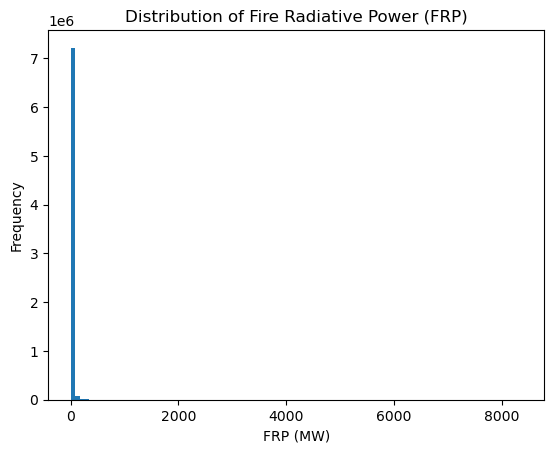

In [14]:
## FRP Distribution
plt.figure()
df["frp"].plot(kind="hist", bins=100)
plt.title("Distribution of Fire Radiative Power (FRP)")
plt.xlabel("FRP (MW)")
plt.show()


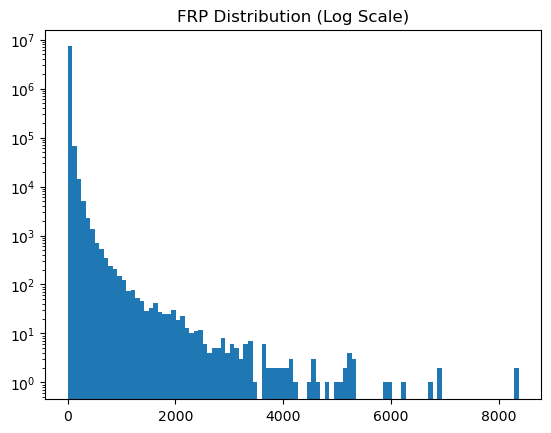

In [15]:
plt.figure()
plt.hist(df["frp"], bins=100)
plt.yscale("log")
plt.title("FRP Distribution (Log Scale)")
plt.show()


# STEP 3D: MODIS vs VIIRS COMPARISON

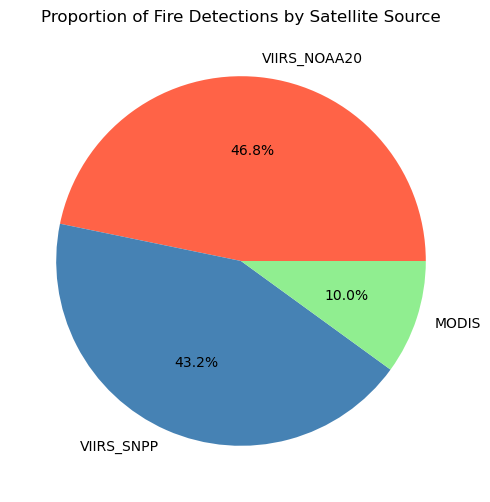

In [16]:
#### Fire Counts by Satellite Source

plt.figure(figsize=(6,6))
df["source"].value_counts().plot(kind="pie", autopct='%1.1f%%', colors=["#FF6347","#4682B4","#90EE90"])
plt.title("Proportion of Fire Detections by Satellite Source")
plt.ylabel("")  # remove y-label
plt.show()


# STEP 3E: CONFIDENCE & SEVERITY

/tmp/ipykernel_1493/1927197518.py:6: FutureWarning:

Passing `palette` without assigning `hue` is deprecated.



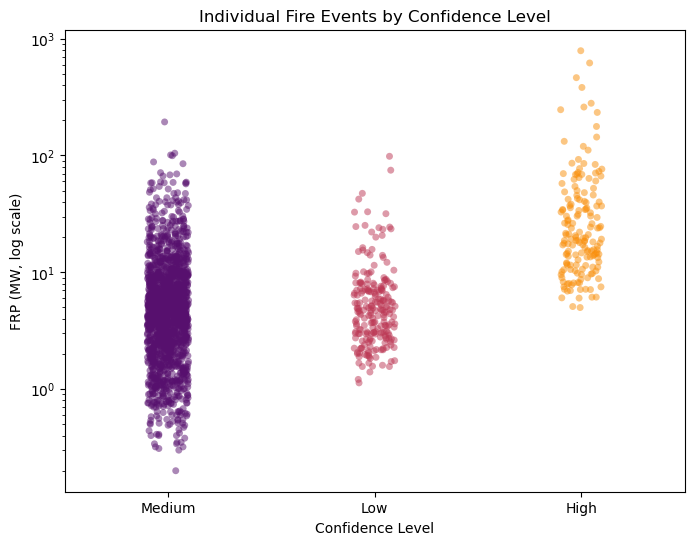

In [18]:
##### Scatter + Jitter Plot (Individual Detections)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.stripplot(x="confidence_level", y="frp", data=df.sample(2000), 
              jitter=True, palette="inferno", alpha=0.5)
plt.yscale("log")
plt.title("Individual Fire Events by Confidence Level")
plt.xlabel("Confidence Level")
plt.ylabel("FRP (MW, log scale)")
plt.show()



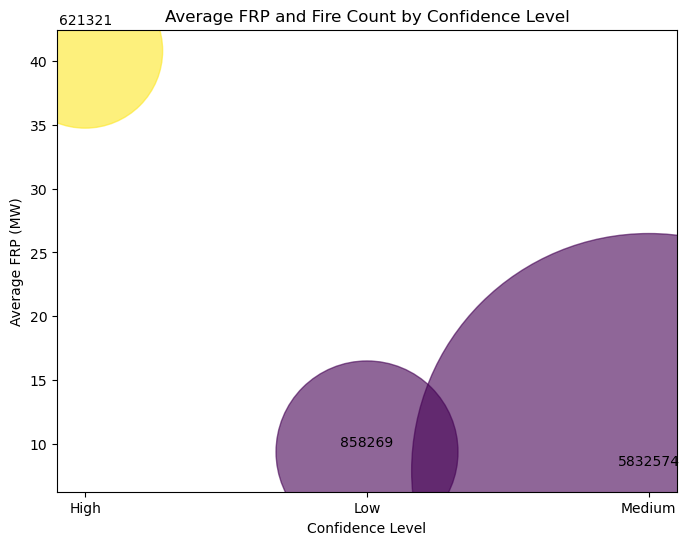

In [19]:
### Bubble Chart (Average FRP + Count per Confidence Level)

summary = df.groupby("confidence_level").agg({"frp":"mean","acq_date":"count"}).reset_index()
summary.rename(columns={"acq_date":"count"}, inplace=True)

plt.figure(figsize=(8,6))
plt.scatter(summary["confidence_level"], summary["frp"], s=summary["count"]/50, alpha=0.6, c=[0.8,0.2,0.2])
plt.title("Average FRP and Fire Count by Confidence Level")
plt.xlabel("Confidence Level")
plt.ylabel("Average FRP (MW)")
for i, row in summary.iterrows():
    plt.text(row["confidence_level"], row["frp"]*1.05, row["count"], ha="center")
plt.show()
